In [288]:
import os
import json
import ast
import pandas as pd
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt

In [289]:
df = pd.read_parquet('data/segments.parquet')

In [290]:
df.columns

Index(['id', 'name', 'activity_type', 'distance', 'average_grade',
       'elevation_high', 'elevation_low', 'total_elevation_gain',
       'start_latlng', 'end_latlng', 'country', 'state', 'city',
       'effort_count', 'athlete_count', 'date', 'start_to_finish_distance'],
      dtype='object')

In [291]:
df = df[df['country'].str.contains('Cz',na=True)]

In [292]:
df['lat'] = df['start_latlng'].apply(lambda x: x[0])
df['lon'] = df['start_latlng'].apply(lambda x: x[1])

In [293]:
admin_country = ox.geocode_to_gdf('Czech Republic')

In [294]:
points_gdf = gpd.GeoDataFrame(
    df, 
    geometry=gpd.points_from_xy(df['lon'], df['lat']),
    crs="EPSG:4326"
)

In [295]:
run_points = points_gdf[points_gdf['activity_type'] == 'Run']
run_track_points = points_gdf[(points_gdf['activity_type'] == 'Run') & (points_gdf['start_to_finish_distance'] < 0.03)]
ride_points = points_gdf[points_gdf['activity_type'] == 'Ride']
hike_points = points_gdf[points_gdf['activity_type'] == 'Hike']

In [296]:
len(run_points)

1433

In [297]:
len(ride_points)

1570

In [298]:
len(hike_points)

723

## Run Segments

<Axes: >

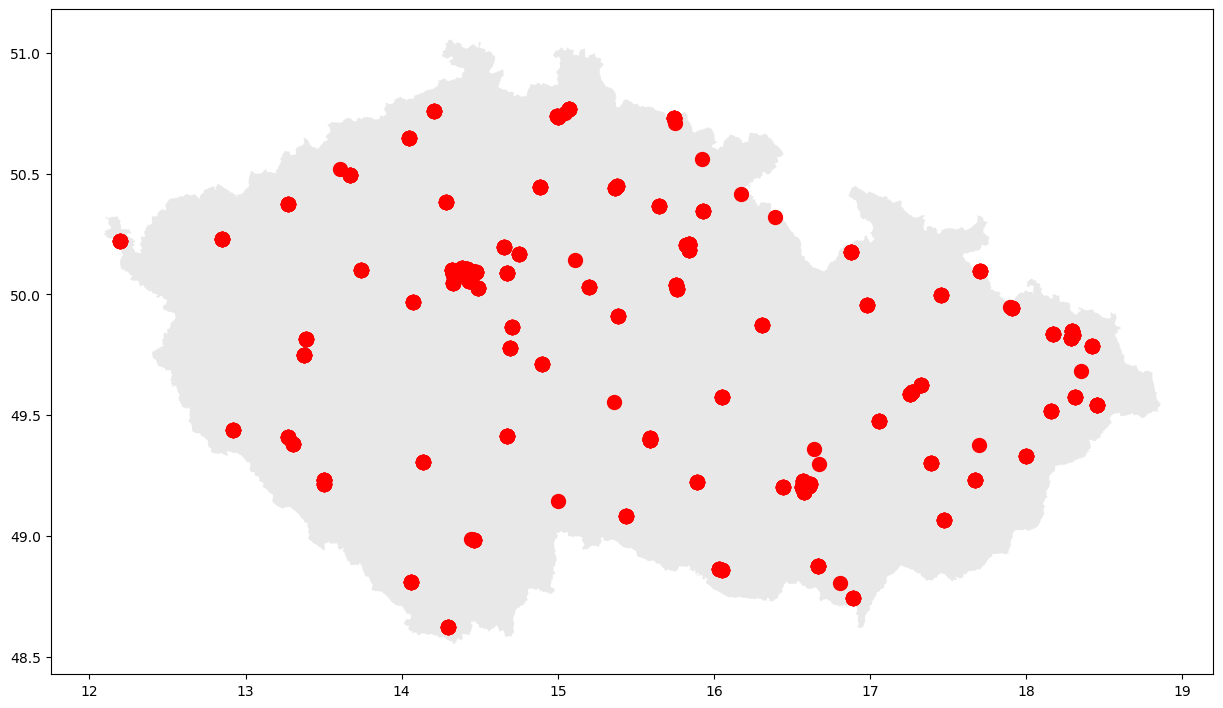

In [300]:
fig, ax = plt.subplots(figsize=(15, 10))
admin_country.plot(ax=ax, alpha=0.5, color='lightgray')
run_points.plot(ax=ax, color='red', marker='o', label='Run', markersize=100)

### Tracks

<Axes: >

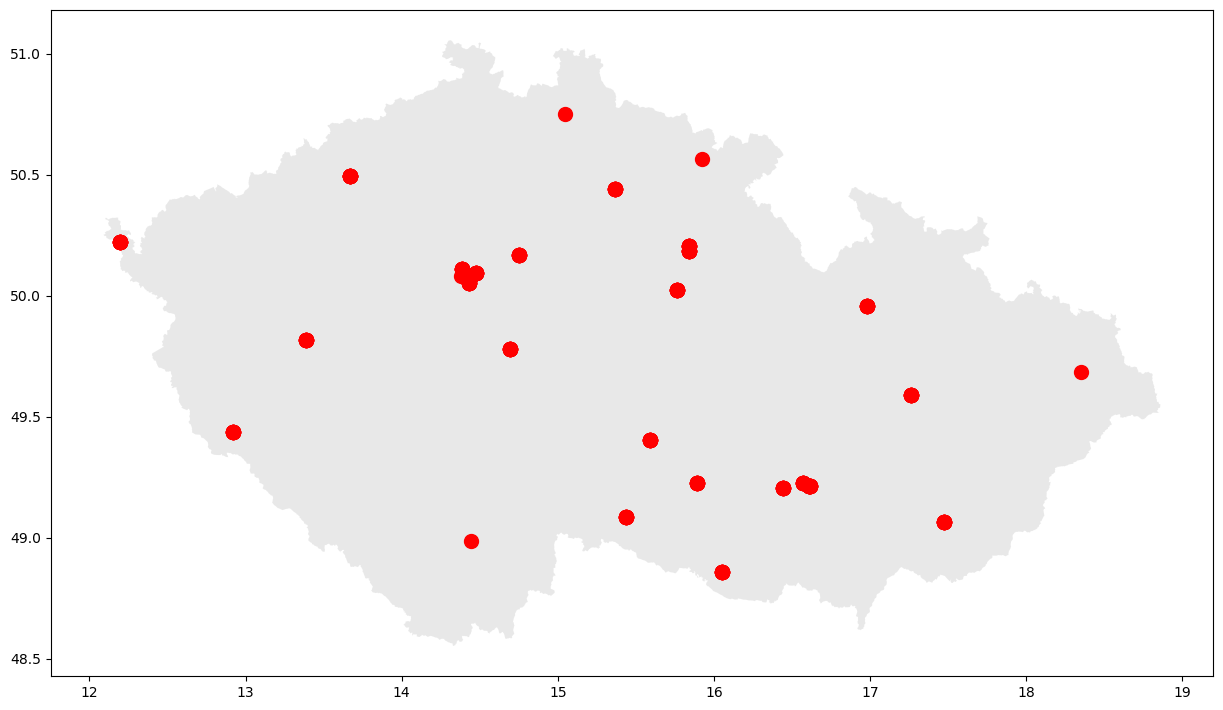

In [302]:
fig, ax = plt.subplots(figsize=(15, 10))
admin_country.plot(ax=ax, alpha=0.5, color='lightgray')
run_track_points.plot(ax=ax, color='red', marker='o', label='Run', markersize=100)

## Ride Segments

<Axes: >

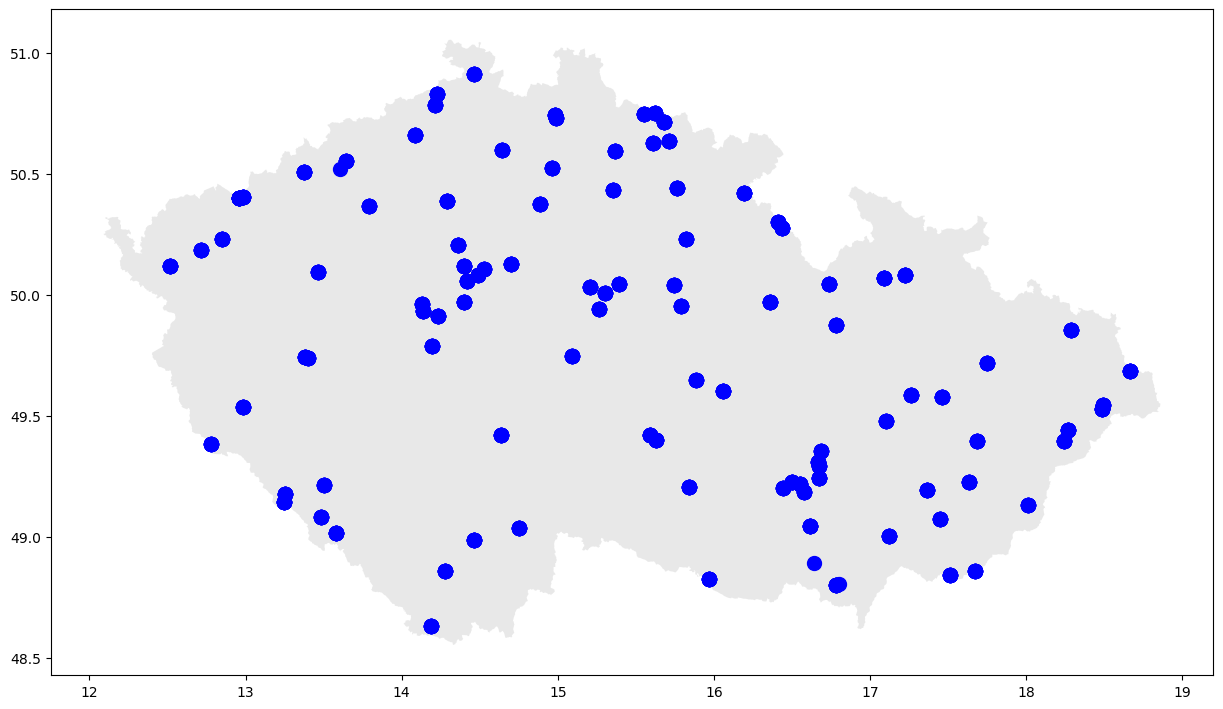

In [304]:
fig, ax = plt.subplots(figsize=(15, 10))
admin_country.plot(ax=ax, alpha=0.5, color='lightgray')
ride_points.plot(ax=ax, color='blue', marker='o', label='Ride', markersize=100)

## Hike segments

<Axes: >

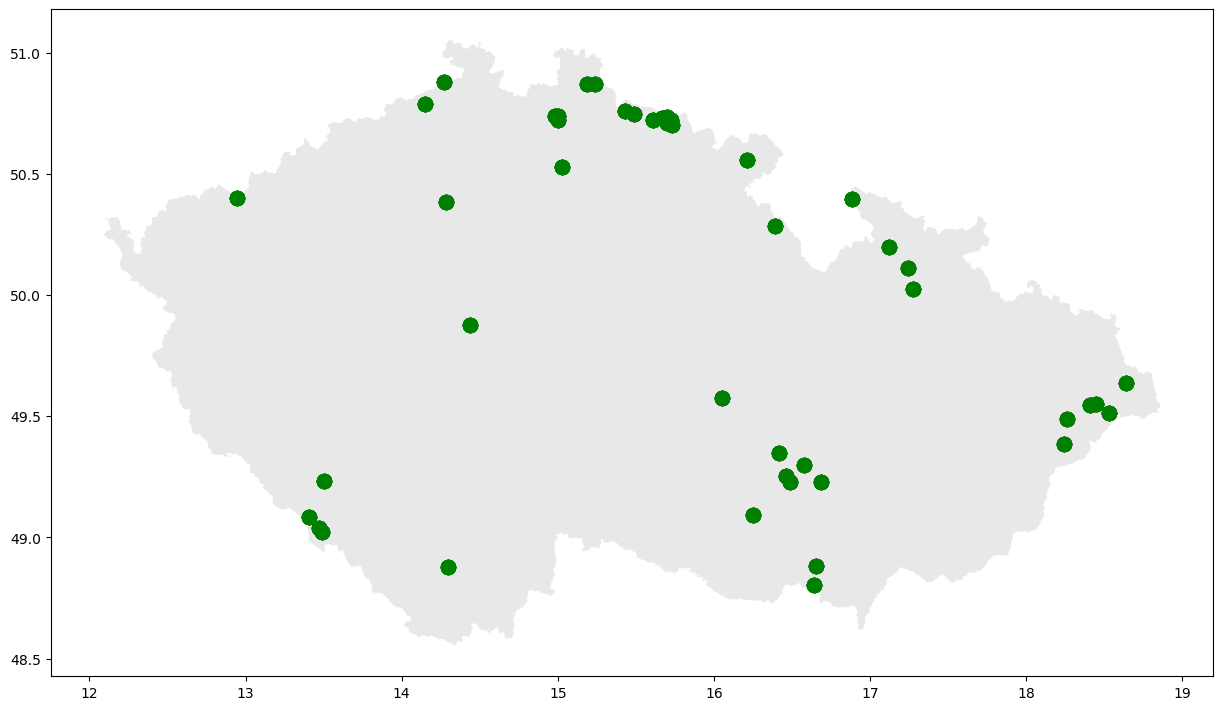

In [306]:
fig, ax = plt.subplots(figsize=(15, 10))
admin_country.plot(ax=ax, alpha=0.5, color='lightgray')
hike_points.plot(ax=ax, color='green', marker='o', label='Hike', markersize=100)